# Modelo de regresion lineal con datos socio demograficos y de salud

En este cuaderno desarrollo un analisis exploratorio completo sobre datos socio demograficos y recursos sanitarios a nivel de condado en Estados Unidos. El objetivo es estudiar si estas variables ayudan a explicar un indicador de salud y, a partir de ahi, construir y optimizar modelos de regresion.

La variable objetivo elegida es `diabetes_prevalence` porque:

- Es interpretable desde salud publica.
- Tiene relacion plausible con pobreza, educacion, envejecimiento e infraestructura sanitaria.
- Permite construir un problema de regresion con una narrativa de negocio clara.


## Hoja de ruta

1. Cargar el dataset y dejar una ruta reproducible.
2. Hacer un EDA completo: estructura, calidad del dato, distribuciones, correlaciones y outliers.
3. Seleccionar variables explicativas con criterio analitico, evitando fuga de informacion.
4. Dividir en train y test.
5. Entrenar una regresion lineal base y un modelo Lasso.
6. Estudiar la evolucion del `R2` cuando cambia `alpha`.
7. Optimizar el enfoque reduciendo multicolinealidad y creando variables mas comparables.
8. Comparar resultados y extraer conclusiones.


## Paso 1: Carga del conjunto de datos

Primero preparo el entorno de trabajo, defino rutas y cargo el CSV. Si el archivo ya existe en `data/raw`, reutilizo esa copia local para que el notebook siga funcionando incluso si la URL no responde.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Ajustes globales para que el notebook sea mas legible y estable.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

project_dir = Path.cwd().resolve().parent
raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"

raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)


In [2]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
raw_path = raw_dir / "demographic_health_data.csv"

if raw_path.exists():
    total_data = pd.read_csv(raw_path)
    source_used = f"archivo local: {raw_path}"
else:
    total_data = pd.read_csv(url)
    total_data.to_csv(raw_path, index=False)
    source_used = f"URL descargada y guardada en: {raw_path}"

print(source_used)
total_data.head()


archivo local: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/raw/demographic_health_data.csv


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.207,7637,13.735,6878,12.370,7089,12.750,7582,13.636,7738,13.917,5826,10.478,4050,7.284,2014,3.622,42660,76.725,10915,19.631,267,0.480,681,1.225,62,0.112,1016,1.827,55601,158,455,11.800,9.600,2.200,0.000,0.700,0.600,4204,12119,10552,10291,11.300,32.600,28.400,27.700,7587,13.800,19.300,19.500,59338,53628,65048,25957,25015,942,3.600,59338,119.000,217.100,196.700,77.200,71.200,7.600,6.900,28.859,6.086,1.149,25.993,21.249,72.142,6,55036,10523,19.100,Autauga,Alabama,1,1,42438,47.600,45.400,49.400,20181,35.800,34.200,37.300,15193,7.900,7.200,8.700,3345,8.600,7.300,9.900,3644,12.900,11.900,13.800,5462,3.100,2.900,3.300,1326,3
1,1003,218022,24757,11.355,26913,12.344,23579,10.815,25213,11.564,27338,12.539,29986,13.754,29932,13.729,20936,9.603,9368,4.297,190301,87.285,19492,8.940,1684,0.772,2508,1.150,146,0.067,3891,1.785,218022,5403,2190,10.500,10.300,0.100,0.500,24.300,24.800,14310,40579,46025,46075,9.700,27.600,31.300,31.300,21069,9.800,13.900,13.100,57588,54437,60739,93849,90456,3393,3.600,57588,115.500,217.100,196.700,77.200,71.200,7.600,6.900,113.162,23.864,4.505,101.922,83.322,282.883,51,203360,53519,26.300,Baldwin,Alabama,1,3,170912,40.200,38.200,42.300,68790,29.700,28.400,31.000,50761,7.800,7.000,8.700,13414,8.600,7.200,10.100,14692,12.000,11.000,13.100,20520,3.200,3.000,3.500,5479,4
2,1005,24881,2732,10.980,2960,11.897,3268,13.135,3201,12.865,3074,12.355,3278,

In [3]:
print(f"Ruta usada: {raw_path}")
print(f"Filas y columnas: {total_data.shape}")


Ruta usada: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/raw/demographic_health_data.csv
Filas y columnas: (3140, 108)


## Paso 2: EDA completo

Antes de modelar conviene entender bien el dataset. En esta etapa reviso:

- calidad del dato,
- tipos de variables,
- valores faltantes y duplicados,
- distribucion de la variable objetivo,
- relaciones entre predictores y target,
- riesgo de multicolinealidad.

Ademas, evito usar como predictores otras enfermedades o intervalos de confianza del propio indicador porque eso produciria fuga de informacion y un modelo poco defendible.


In [4]:
rows, cols = total_data.shape
print(f"El dataset contiene {rows} filas y {cols} columnas.")


El dataset contiene 3140 filas y 108 columnas.


In [5]:
total_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [6]:
numeric_columns = total_data.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_columns = total_data.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Columnas numericas: {len(numeric_columns)}")
print(f"Columnas no numericas: {len(non_numeric_columns)}")
print(non_numeric_columns)


Columnas numericas: 106
Columnas no numericas: 2
['COUNTY_NAME', 'STATE_NAME']


In [7]:
total_data.describe().T[["mean", "std", "min", "max"]].head(15)


,mean,std,min,max
fips,"30,401.641","15,150.559","1,001.000","56,045.000"
TOT_POP,"104,189.412","333,583.395",88.000,"10,105,518.000"
0-9,"12,740.303","41,807.302",0.000,"1,208,253.000"
0-9 y/o % of total pop,11.871,2.124,0.000,25.461
19-Oct,"13,367.977","42,284.392",0.000,"1,239,139.000"
10-19 y/o % of total pop,12.695,1.815,0.000,23.304
20-29,"14,469.332","49,577.725",0.000,"1,557,073.000"
20-29 y/o % of total pop,12.284,3.126,0.000,37.570
30-39,"13,916.490","48,990.952",11.000,"1,501,844.000"
30-39 y/o % of total pop,11.752,1.697,6.093,22.225


In [8]:
missing_summary = (
    total_data.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)
missing_summary[missing_summary["missing_values"] > 0]


,missing_values


In [9]:
duplicated_rows = total_data.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicated_rows}")


Filas duplicadas exactas: 0


### Hallazgos de calidad del dato

En la inspeccion inicial se observa que:

- el dataset es completamente numerico,
- no hay valores faltantes,
- no hay filas duplicadas exactas.

Esto simplifica mucho el flujo porque no hace falta imputar datos ni aplicar una limpieza agresiva antes del modelado.


### Eleccion de la variable objetivo

La variable objetivo sera `diabetes_prevalence`.

La elijo porque:

- resume un resultado de salud facil de comunicar,
- tiene una relacion teorica razonable con el contexto socioeconomico,
- encaja bien con un problema de regresion donde queremos explicar variaciones entre condados.


In [10]:
target = "diabetes_prevalence"
total_data[target].describe()


count   3,140.000
mean       13.074
std         2.724
min         6.100
25%        11.200
50%        12.800
75%        14.800
max        25.600
Name: diabetes_prevalence, dtype: float64

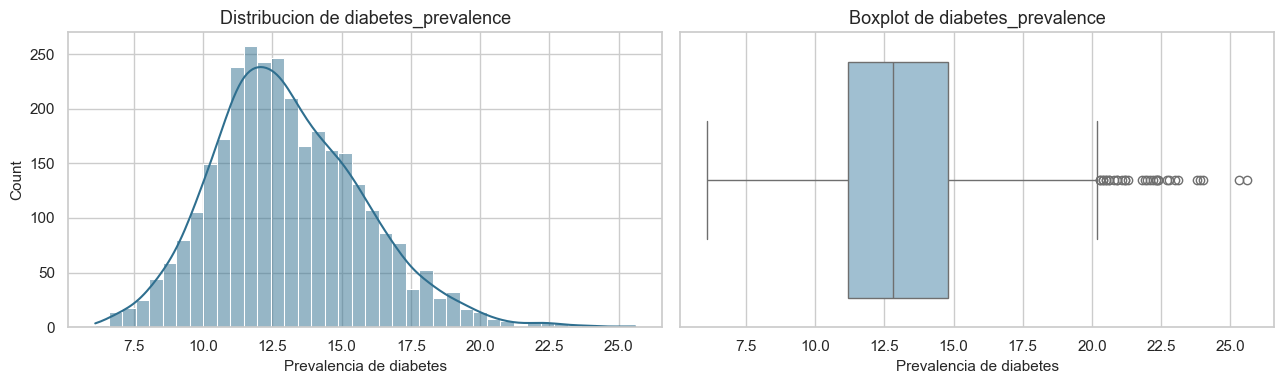

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(total_data[target], kde=True, color="#2f6f8f", ax=axes[0])
axes[0].set_title("Distribucion de diabetes_prevalence")
axes[0].set_xlabel("Prevalencia de diabetes")

sns.boxplot(x=total_data[target], color="#98c1d9", ax=axes[1])
axes[1].set_title("Boxplot de diabetes_prevalence")
axes[1].set_xlabel("Prevalencia de diabetes")

plt.tight_layout()
plt.show()


In [12]:
# Esta tabla solo se usa para justificar variables candidatas.
# No las llevare automaticamente al modelo porque muchas son fuga de informacion.
target_correlations = (
    total_data.corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

pd.DataFrame(
    {
        "top_positive": target_correlations.head(12),
        "top_negative": target_correlations.tail(12).sort_values(),
    }
)


,top_positive,top_negative
% White-alone,NaN,-0.410
Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),NaN,-0.402
Active Physicians per 100000 Population 2018 (AAMC),NaN,-0.324
Active Primary Care Physicians per 100000 Population 2018 (AAMC),NaN,-0.388
CI90LBINC_2018,NaN,-0.721
CI90UBINC_2018,NaN,-0.720
CKD_Lower 95% CI,0.925,NaN
CKD_Upper 95% CI,0.907,NaN
CKD_prevalence,0.919,NaN
Heart disease_Lower 95% CI,0.856,NaN


La tabla anterior muestra algo importante: las variables con mayor correlacion son otras metricas clinicas o incluso intervalos de confianza del mismo fenomeno. Eso no seria una buena practica para este ejercicio.

Por eso voy a construir una seleccion mas interpretable, centrada en:

- educacion,
- pobreza, empleo e ingresos,
- estructura demografica,
- recursos sanitarios,
- ruralidad.


In [13]:
# Seleccion inicial de variables explicativas.
# Incluyo una mezcla de factores socioeconomicos y recursos de salud.
base_features = [
    "Percent of adults with less than a high school diploma 2014-18",
    "Percent of adults with a bachelor's degree or higher 2014-18",
    "PCTPOVALL_2018",
    "Unemployment_rate_2018",
    "Median_Household_Income_2018",
    "% Black-alone",
    "% White-alone",
    "Percent of Population Aged 60+",
    "Active Physicians per 100000 Population 2018 (AAMC)",
    "Active Primary Care Physicians per 100000 Population 2018 (AAMC)",
    "Total nurse practitioners (2019)",
    "Total Hospitals (2019)",
    "ICU Beds_x",
    "Urban_rural_code",
]

model_data = total_data[base_features + [target]].copy()
model_data.head()


,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,Unemployment_rate_2018,Median_Household_Income_2018,% Black-alone,% White-alone,Percent of Population Aged 60+,Active Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total Hospitals (2019),ICU Beds_x,Urban_rural_code,diabetes_prevalence
0,11.300,27.700,13.800,3.600,59338,19.631,76.725,19.100,217.100,77.200,28.859,1.149,6,3,12.900
1,9.700,31.300,9.800,3.600,57588,8.940,87.285,26.300,217.100,77.200,113.162,4.505,51,4,12.000
2,27.000,12.200,30.900,5.200,34382,48.398,49.070,23.500,217.100,77.200,12.914,0.514,5,6,19.700
3,16.800,11.500,21.800,4.000,46064,21.295,76.835,21.100,217.100,77.200,11.626,0.463,0,2,14.100
4,19.800,12.600,13.200,3.500,50412,1.642,95.878,23.600,217.100,77.200,30.021,1.195,6,2,13.500


In [14]:
model_data.corr(numeric_only=True)[target].sort_values(ascending=False).to_frame("correlation_with_target")


,correlation_with_target
diabetes_prevalence,1.000
PCTPOVALL_2018,0.735
Percent of adults with less than a high school diploma 2014-18,0.699
Unemployment_rate_2018,0.491
% Black-alone,0.475
Urban_rural_code,0.340
Percent of Population Aged 60+,0.259
ICU Beds_x,-0.147
Total nurse practitioners (2019),-0.195
Total Hospitals (2019),-0.207


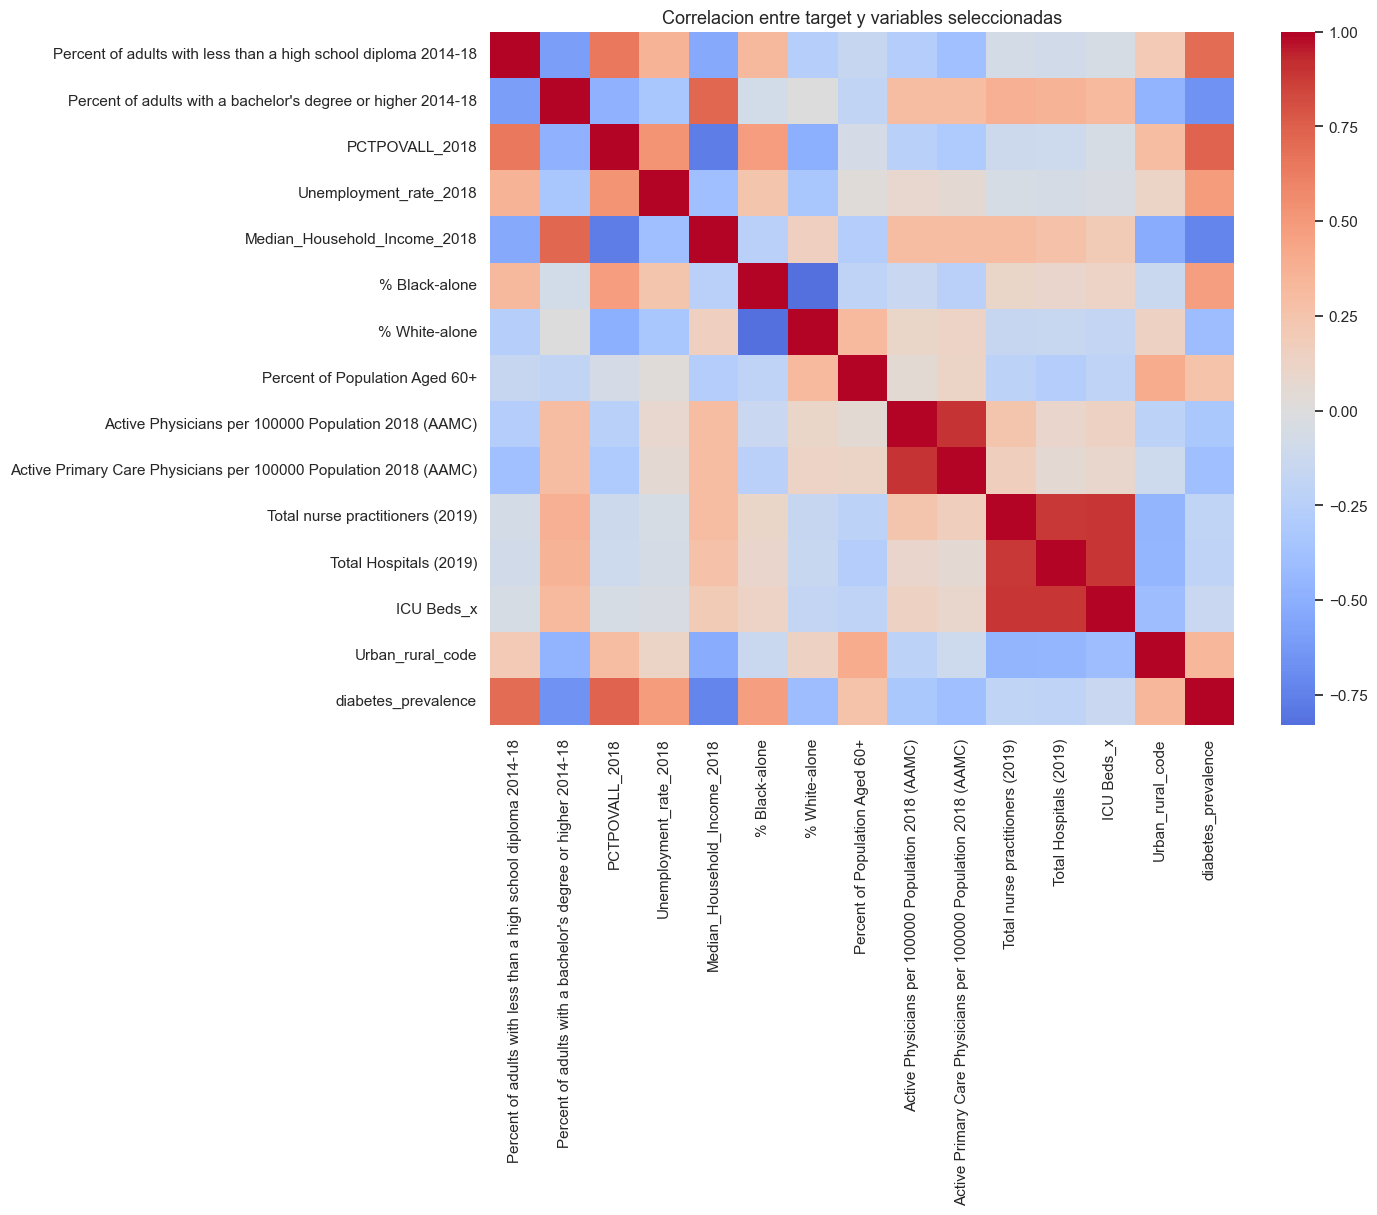

In [15]:
plt.figure(figsize=(12, 9))
sns.heatmap(model_data.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlacion entre target y variables seleccionadas")
plt.show()


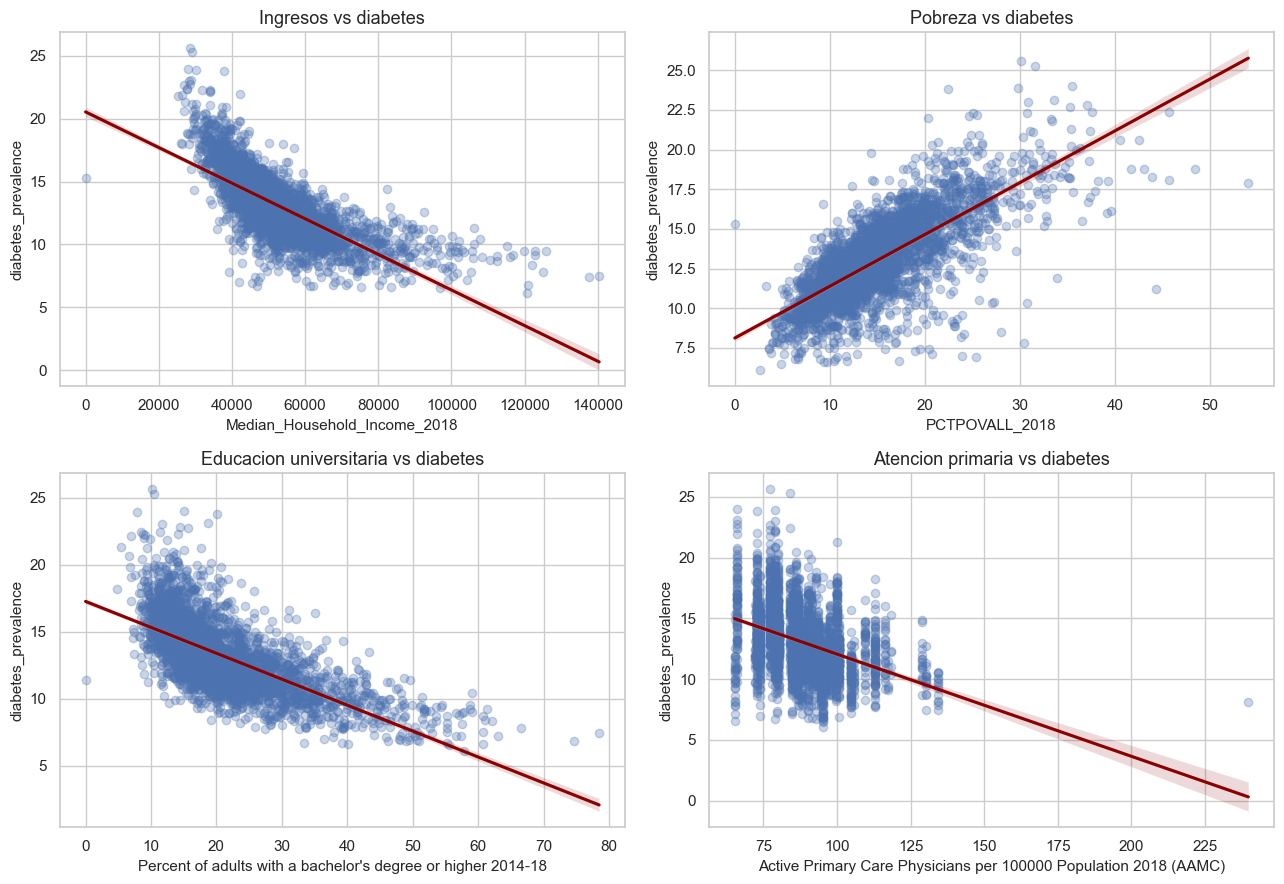

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.regplot(
    data=model_data,
    x="Median_Household_Income_2018",
    y=target,
    scatter_kws={"alpha": 0.30},
    line_kws={"color": "darkred"},
    ax=axes[0, 0],
)
axes[0, 0].set_title("Ingresos vs diabetes")

sns.regplot(
    data=model_data,
    x="PCTPOVALL_2018",
    y=target,
    scatter_kws={"alpha": 0.30},
    line_kws={"color": "darkred"},
    ax=axes[0, 1],
)
axes[0, 1].set_title("Pobreza vs diabetes")

sns.regplot(
    data=model_data,
    x="Percent of adults with a bachelor's degree or higher 2014-18",
    y=target,
    scatter_kws={"alpha": 0.30},
    line_kws={"color": "darkred"},
    ax=axes[1, 0],
)
axes[1, 0].set_title("Educacion universitaria vs diabetes")

sns.regplot(
    data=model_data,
    x="Active Primary Care Physicians per 100000 Population 2018 (AAMC)",
    y=target,
    scatter_kws={"alpha": 0.30},
    line_kws={"color": "darkred"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Atencion primaria vs diabetes")

plt.tight_layout()
plt.show()


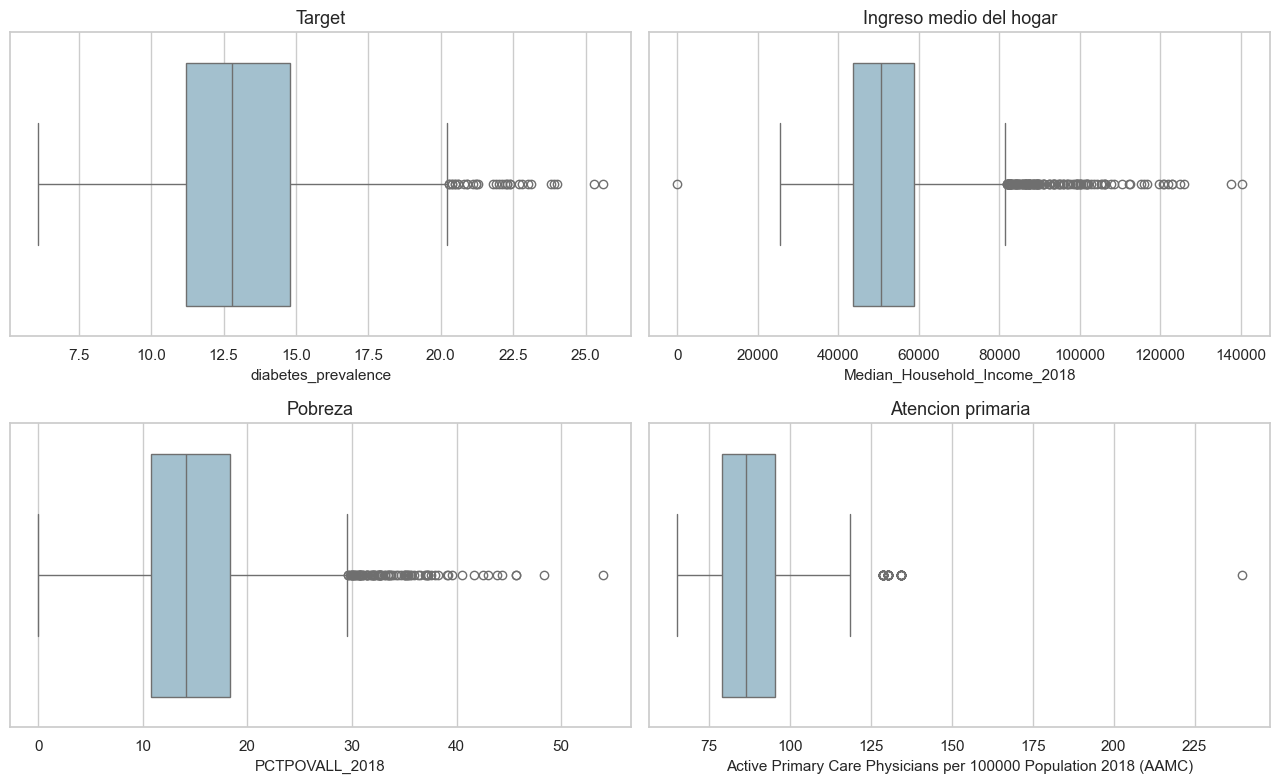

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.boxplot(x=model_data[target], ax=axes[0, 0], color="#9cc3d5")
axes[0, 0].set_title("Target")

sns.boxplot(x=model_data["Median_Household_Income_2018"], ax=axes[0, 1], color="#9cc3d5")
axes[0, 1].set_title("Ingreso medio del hogar")

sns.boxplot(x=model_data["PCTPOVALL_2018"], ax=axes[1, 0], color="#9cc3d5")
axes[1, 0].set_title("Pobreza")

sns.boxplot(
    x=model_data["Active Primary Care Physicians per 100000 Population 2018 (AAMC)"],
    ax=axes[1, 1],
    color="#9cc3d5",
)
axes[1, 1].set_title("Atencion primaria")

plt.tight_layout()
plt.show()


### Lectura del EDA

Las relaciones mas claras sugieren que:

- a mayor pobreza y desempleo, mayor prevalencia de diabetes,
- a mayor ingreso y mayor educacion universitaria, menor prevalencia,
- los recursos de atencion primaria tienden a asociarse con menor prevalencia, aunque con dispersion,
- hay outliers, pero parecen observaciones reales de condados con contextos muy distintos y no errores evidentes.


### Revision de multicolinealidad

En la seleccion inicial aparecen varias variables muy parecidas entre si. Antes de optimizar, quiero medir ese problema porque puede volver inestables los coeficientes y hacer que Lasso penalice de forma poco informativa.


In [18]:
# Funcion auxiliar para aproximar VIF sin depender de statsmodels.
def approximate_vif(dataframe):
    vif_rows = []
    for column in dataframe.columns:
        y_aux = dataframe[column]
        X_aux = dataframe.drop(columns=[column])
        r2_aux = LinearRegression().fit(X_aux, y_aux).score(X_aux, y_aux)
        vif_value = np.inf if r2_aux >= 0.999999 else 1 / (1 - r2_aux)
        vif_rows.append({"feature": column, "approx_vif": vif_value})
    return pd.DataFrame(vif_rows).sort_values("approx_vif", ascending=False)

approximate_vif(model_data.drop(columns=[target])).round(3)


,feature,approx_vif
10,Total nurse practitioners (2019),6.874
9,Active Primary Care Physicians per 100000 Popu...,6.868
8,Active Physicians per 100000 Population 2018 (...,6.667
12,ICU Beds_x,6.584
11,Total Hospitals (2019),6.555
4,Median_Household_Income_2018,5.628
2,PCTPOVALL_2018,5.450
6,% White-alone,4.523
5,% Black-alone,3.951
1,Percent of adults with a bachelor's degree or ...,3.129


In [19]:
correlation_pairs = (
    model_data.drop(columns=[target])
    .corr()
    .abs()
    .where(lambda matrix: np.triu(np.ones(matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)
correlation_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]
correlation_pairs[correlation_pairs["abs_correlation"] > 0.80]


,feature_1,feature_2,abs_correlation
0,Active Physicians per 100000 Population 2018 (...,Active Primary Care Physicians per 100000 Popu...,0.897
1,Total Hospitals (2019),ICU Beds_x,0.889
2,Total nurse practitioners (2019),ICU Beds_x,0.887
3,Total nurse practitioners (2019),Total Hospitals (2019),0.879
4,% Black-alone,% White-alone,0.829


La multicolinealidad confirma tres decisiones de mejora:

- quedarme con `Active Primary Care Physicians...` y no con dos medidas casi duplicadas de personal medico,
- transformar conteos absolutos a tasas por 100000 habitantes para poder comparar condados grandes y pequenos,
- simplificar el set de variables sin perder interpretabilidad.

Esa sera la optimizacion principal del paso 4.


## Paso 3: Construccion del modelo base

Empiezo con la seleccion inicial para construir una linea base. Luego entreno:

- una regresion lineal,
- un modelo Lasso con regularizacion moderada,
- una curva de `R2` variando `alpha`.


In [20]:
X = model_data.drop(columns=[target])
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")


X_train: (2512, 14)
X_test: (628, 14)


In [21]:
# Guardo copias para dejar trazabilidad del proceso.
clean_path = processed_dir / "demographic_health_model_data.csv"
train_path = processed_dir / "demographic_health_train.csv"
test_path = processed_dir / "demographic_health_test.csv"

train_data = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_data = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

model_data.to_csv(clean_path, index=False)
train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

print(clean_path)
print(train_path)
print(test_path)


/Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/demographic_health_model_data.csv
/Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/demographic_health_train.csv
/Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/demographic_health_test.csv


In [22]:
def regression_metrics(y_true, y_pred):
    return {
        "mae": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "r2": round(float(r2_score(y_true, y_pred)), 4),
    }

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)
linear_metrics = regression_metrics(y_test, linear_pred)

linear_metrics


{'mae': 0.8025, 'rmse': 1.0576, 'r2': 0.8609}

In [23]:
lasso_model = Lasso(alpha=0.1, max_iter=50000)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)
lasso_metrics = regression_metrics(y_test, lasso_pred)

lasso_metrics


{'mae': 0.8262, 'rmse': 1.0884, 'r2': 0.8527}

In [24]:
base_comparison = pd.DataFrame(
    [
        {"model": "linear_regression_base", **linear_metrics},
        {"model": "lasso_alpha_0.1_base", **lasso_metrics},
    ]
)
base_comparison


,model,mae,rmse,r2
0,linear_regression_base,0.802,1.058,0.861
1,lasso_alpha_0.1_base,0.826,1.088,0.853


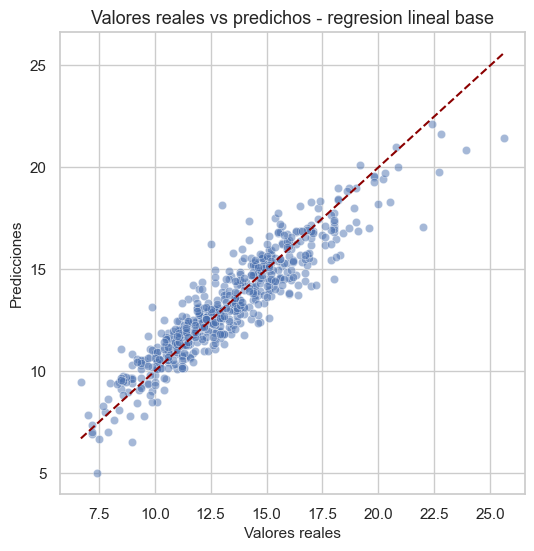

In [25]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=linear_pred, alpha=0.50)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
)
plt.title("Valores reales vs predichos - regresion lineal base")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.show()


### Evolucion del `R2` cuando cambia `alpha`

Ahora mido como responde Lasso a diferentes niveles de regularizacion. Para aproximar el caso `alpha = 0`, uso `0.0001`, porque `Lasso` no acepta cero exacto.


In [26]:
alpha_values = [0.0, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20]
alpha_results = []

for alpha in alpha_values:
    effective_alpha = 0.0001 if alpha == 0.0 else alpha
    alpha_model = Lasso(alpha=effective_alpha, max_iter=50000)
    alpha_model.fit(X_train_scaled, y_train)
    alpha_pred = alpha_model.predict(X_test_scaled)

    alpha_results.append(
        {
            "alpha_shown": alpha,
            "alpha_used": effective_alpha,
            "r2": float(r2_score(y_test, alpha_pred)),
            "non_zero_coefficients": int((alpha_model.coef_ != 0).sum()),
        }
    )

alpha_results_df = pd.DataFrame(alpha_results)
alpha_results_df


,alpha_shown,alpha_used,r2,non_zero_coefficients
0,0.000,0.000,0.861,14
1,0.000,0.000,0.861,14
2,0.001,0.001,0.861,14
3,0.010,0.010,0.861,12
4,0.050,0.050,0.858,9
5,0.100,0.100,0.853,9
6,0.500,0.500,0.706,7
7,1.000,1.000,0.491,4
8,2.000,2.000,-0.003,0
9,5.000,5.000,-0.003,0


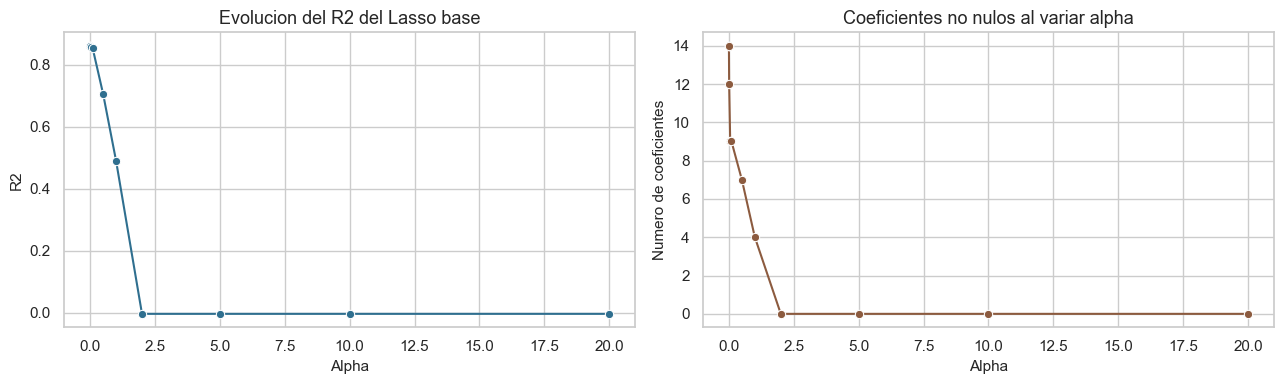

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(data=alpha_results_df, x="alpha_shown", y="r2", marker="o", color="#2f6f8f", ax=axes[0])
axes[0].set_title("Evolucion del R2 del Lasso base")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")

sns.lineplot(
    data=alpha_results_df,
    x="alpha_shown",
    y="non_zero_coefficients",
    marker="o",
    color="#8c5b3f",
    ax=axes[1],
)
axes[1].set_title("Coeficientes no nulos al variar alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Numero de coeficientes")

plt.tight_layout()
plt.show()


### Lectura de la curva de regularizacion

El resultado del paso 3 deja una idea clara: cuando `alpha` es pequeno, Lasso se comporta casi igual que la regresion lineal. En cambio, cuando la penalizacion sube demasiado, el modelo pierde muchos coeficientes y el `R2` cae con fuerza.

Por eso la optimizacion no va a consistir solo en probar mas `alpha`, sino tambien en mejorar la representacion de algunas variables.


## Paso 4: Optimizacion del modelo

Para optimizar el enfoque hago dos cambios:

- convierto algunos conteos absolutos a tasas por 100000 habitantes,
- reduzco redundancia entre variables muy correlacionadas.

Esto es mas interesante que solo mover un hiperparametro, porque mejora la comparabilidad entre condados y reduce multicolinealidad.


In [28]:
optimized_data = total_data.copy()

# Transformo conteos absolutos en tasas para comparar condados de distinto tamano.
optimized_data["nurse_practitioners_per_100k"] = np.where(
    optimized_data["TOT_POP"] > 0,
    optimized_data["Total nurse practitioners (2019)"] / optimized_data["TOT_POP"] * 100000,
    0,
)

optimized_data["hospitals_per_100k"] = np.where(
    optimized_data["TOT_POP"] > 0,
    optimized_data["Total Hospitals (2019)"] / optimized_data["TOT_POP"] * 100000,
    0,
)

optimized_data["icu_beds_per_100k"] = np.where(
    optimized_data["TOT_POP"] > 0,
    optimized_data["ICU Beds_x"] / optimized_data["TOT_POP"] * 100000,
    0,
)

optimized_features = [
    "Percent of adults with less than a high school diploma 2014-18",
    "Percent of adults with a bachelor's degree or higher 2014-18",
    "PCTPOVALL_2018",
    "Unemployment_rate_2018",
    "Median_Household_Income_2018",
    "% Black-alone",
    "% White-alone",
    "Percent of Population Aged 60+",
    "Active Primary Care Physicians per 100000 Population 2018 (AAMC)",
    "nurse_practitioners_per_100k",
    "icu_beds_per_100k",
    "Urban_rural_code",
]

optimized_model_data = optimized_data[optimized_features + [target]].copy()
optimized_model_data.head()


,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,Unemployment_rate_2018,Median_Household_Income_2018,% Black-alone,% White-alone,Percent of Population Aged 60+,Active Primary Care Physicians per 100000 Population 2018 (AAMC),nurse_practitioners_per_100k,icu_beds_per_100k,Urban_rural_code,diabetes_prevalence
0,11.300,27.700,13.800,3.600,59338,19.631,76.725,19.100,77.200,51.904,10.791,3,12.900
1,9.700,31.300,9.800,3.600,57588,8.940,87.285,26.300,77.200,51.904,23.392,4,12.000
2,27.000,12.200,30.900,5.200,34382,48.398,49.070,23.500,77.200,51.904,20.096,6,19.700
3,16.800,11.500,21.800,4.000,46064,21.295,76.835,21.100,77.200,51.904,0.000,2,14.100
4,19.800,12.600,13.200,3.500,50412,1.642,95.878,23.600,77.200,51.904,10.373,2,13.500


In [29]:
approximate_vif(optimized_model_data.drop(columns=[target])).round(3)


,feature,approx_vif
2,PCTPOVALL_2018,5.429
4,Median_Household_Income_2018,5.407
6,% White-alone,4.313
5,% Black-alone,3.837
1,Percent of adults with a bachelor's degree or ...,2.971
0,Percent of adults with less than a high school...,2.556
11,Urban_rural_code,1.704
7,Percent of Population Aged 60+,1.646
3,Unemployment_rate_2018,1.634
8,Active Primary Care Physicians per 100000 Popu...,1.491


In [30]:
X_opt = optimized_model_data.drop(columns=[target])
y_opt = optimized_model_data[target]

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt,
    y_opt,
    test_size=0.20,
    random_state=42,
)

scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_train_opt)
X_test_opt_scaled = scaler_opt.transform(X_test_opt)


In [31]:
optimized_linear_model = LinearRegression()
optimized_linear_model.fit(X_train_opt_scaled, y_train_opt)
optimized_linear_pred = optimized_linear_model.predict(X_test_opt_scaled)
optimized_linear_metrics = regression_metrics(y_test_opt, optimized_linear_pred)

optimized_lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=50000),
    param_grid={"alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5]},
    scoring="r2",
    cv=5,
)
optimized_lasso_grid.fit(X_train_opt_scaled, y_train_opt)

optimized_lasso = optimized_lasso_grid.best_estimator_
optimized_lasso_pred = optimized_lasso.predict(X_test_opt_scaled)
optimized_lasso_metrics = regression_metrics(y_test_opt, optimized_lasso_pred)

print(f"Mejor alpha: {optimized_lasso_grid.best_params_['alpha']}")
optimized_lasso_metrics


Mejor alpha: 0.0001


{'mae': 0.7887, 'rmse': 1.0494, 'r2': 0.8631}

In [32]:
final_comparison = pd.DataFrame(
    [
        {"model": "linear_regression_base", **linear_metrics},
        {"model": "lasso_alpha_0.1_base", **lasso_metrics},
        {"model": "linear_regression_optimized", **optimized_linear_metrics},
        {
            "model": f"lasso_optimized_alpha_{optimized_lasso_grid.best_params_['alpha']}",
            **optimized_lasso_metrics,
        },
    ]
)

final_comparison


,model,mae,rmse,r2
0,linear_regression_base,0.802,1.058,0.861
1,lasso_alpha_0.1_base,0.826,1.088,0.853
2,linear_regression_optimized,0.789,1.049,0.863
3,lasso_optimized_alpha_0.0001,0.789,1.049,0.863


In [33]:
coefficients = pd.DataFrame(
    {
        "feature": X_opt.columns,
        "coefficient": optimized_lasso.coef_,
    }
)
coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients.sort_values("abs_coefficient", ascending=False).drop(columns=["abs_coefficient"]).head(12)


,feature,coefficient
7,Percent of Population Aged 60+,1.060
0,Percent of adults with less than a high school...,0.874
6,% White-alone,-0.622
1,Percent of adults with a bachelor's degree or ...,-0.616
2,PCTPOVALL_2018,0.472
8,Active Primary Care Physicians per 100000 Popu...,-0.439
3,Unemployment_rate_2018,0.310
5,% Black-alone,0.190
9,nurse_practitioners_per_100k,0.167
11,Urban_rural_code,-0.130


In [34]:
comparison_path = processed_dir / "regression_model_comparison.csv"
alpha_results_path = processed_dir / "lasso_alpha_results.csv"
optimized_dataset_path = processed_dir / "demographic_health_model_data_optimized.csv"
coefficients_path = processed_dir / "optimized_lasso_coefficients.csv"

final_comparison.to_csv(comparison_path, index=False)
alpha_results_df.to_csv(alpha_results_path, index=False)
optimized_model_data.to_csv(optimized_dataset_path, index=False)
coefficients.sort_values("coefficient", ascending=False).to_csv(coefficients_path, index=False)

print(comparison_path)
print(alpha_results_path)
print(optimized_dataset_path)
print(coefficients_path)


/Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/regression_model_comparison.csv
/Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/lasso_alpha_results.csv
/Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/demographic_health_model_data_optimized.csv
/Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/optimized_lasso_coefficients.csv


## Conclusiones

A partir del analisis puedo defender lo siguiente:

- `diabetes_prevalence` funciona bien como variable objetivo porque responde a factores sociales y sanitarios plausibles.
- El EDA muestra una asociacion consistente entre mayor diabetes y mayor pobreza, menor nivel educativo, menor ingreso y mayor envejecimiento.
- Los recursos de atencion primaria parecen relacionarse con una menor prevalencia, aunque no explican por si solos todo el fenomeno.
- La regresion lineal base ya ofrece un rendimiento alto, lo que indica que las variables elegidas contienen bastante informacion.
- Lasso solo mantiene ese rendimiento cuando `alpha` es muy pequeno; con regularizacion alta, el modelo se simplifica demasiado y pierde capacidad predictiva.
- La optimizacion mas util no fue subir la penalizacion, sino mejorar las variables: convertir algunos conteos a tasas por habitante y reducir redundancias.
- El modelo optimizado queda algo mas limpio e interpretable, con una mejora ligera en metricas y una lectura mas defendible de los coeficientes.

En resumen, si existe una relacion clara entre el contexto socio demografico, algunos recursos sanitarios y la prevalencia de diabetes en los condados de Estados Unidos. El resultado tambien sugiere que la desigualdad social pesa mas que la pura cantidad bruta de infraestructura hospitalaria.
